In [342]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [343]:
import warnings
warnings.filterwarnings("ignore")

In [344]:
import os 
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from statsmodels.stats.diagnostic import het_arch

In [345]:
from proj.features import transforms
from proj.data.storage import LocalStorage
from proj.evaluation.backtester import Backtester
from proj.evaluation.engine import greedy_forward_feature_selection, greedy_hyperparam_tuning, model_selection, evaluate_models
from proj.utils.paths import find_project_root, build_paths
from proj.data.merge_helpers import *


In [346]:
repo_root = find_project_root()
paths = build_paths(repo_root)

In [347]:
style_path = os.path.join(paths['SRC'], 'proj', 'utils', 'styler.mplstyle')
plt.style.use(style_path)

In [348]:
storage = LocalStorage(base_dir=Path("../data"))


In [349]:
oos = storage.read_parquet("external/oos_predictions.parquet")
oos['oos'] = True
max_oos = oos.index.max()

In [350]:
gold = storage.read_parquet("gold/modeling_table.parquet")
gold = gold[['ret_xle', 'rv_xle']].loc[:max_oos]
# gold['ret_xle'] = gold['ret_xle'] / 100

In [351]:
df = gold.merge(oos,how="left", left_index=True, right_index=True)

In [352]:
df.head()

,ret_xle,rv_xle,truth,"EWMA(rv, λ=0.94)","GARCH(1,1)","GARCHProxyX(1,1,t,X=3)",HAR-RV,HAR-RV-X(3),XLE,oos
timestamp,,,,,,,,,,
2021-01-06 21:00:00+00:00,-0.353565,1.069716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07 21:00:00+00:00,0.466745,2.526196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08 21:00:00+00:00,-1.100503,3.264573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11 21:00:00+00:00,2.614148,2.235152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12 21:00:00+00:00,2.297663,3.475628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [353]:
df[df['oos'].isna()][['rv_xle', 'ret_xle']].corr()

,rv_xle,ret_xle
rv_xle,1.000000,-0.163705
ret_xle,-0.163705,1.000000


In [354]:
df[['rv_xle', 'ret_xle']].corr()

,rv_xle,ret_xle
rv_xle,1.000000,-0.078165
ret_xle,-0.078165,1.000000


In [355]:
for_trading = df[df['oos']== True]

In [356]:
for_trading.head()

,ret_xle,rv_xle,truth,"EWMA(rv, λ=0.94)","GARCH(1,1)","GARCHProxyX(1,1,t,X=3)",HAR-RV,HAR-RV-X(3),XLE,oos
timestamp,,,,,,,,,,
2025-01-14 21:00:00+00:00,1.001602,1.015373,1.015373,1.105876,0.897145,0.955379,1.199641,1.257126,44.135769,True
2025-01-15 21:00:00+00:00,1.394535,1.254940,1.254940,1.100445,0.901654,0.983567,1.086795,1.246676,44.788948,True
2025-01-16 21:00:00+00:00,0.310904,0.504204,0.504204,1.109715,0.929437,1.220608,1.169641,1.496860,45.113117,True
2025-01-17 21:00:00+00:00,0.176134,0.259360,0.259360,1.073384,0.910312,0.678088,0.879542,0.884619,45.461483,True
2025-01-21 21:00:00+00:00,0.154987,0.520784,0.520784,1.024543,0.889930,0.472048,0.619556,0.570331,45.229240,True


### Volatility Targeting

In [357]:

def vol_target_all_pct(
    ret_pct: pd.Series,          # daily returns in % (2.24 means 2.24%)
    var_pct2_daily: pd.Series,   # daily variance in %^2
    target_ann_vol_pct: float = 14.0,  # annual target vol in %
    ann_factor: int = 252,
    w_min: float = 0.0,
    w_max: float = 6.0,
    eps: float = 1e-12,
    power: float = 1.0,
    lag: int = 0,                # 1 = safest default to avoid lookahead
    ret_scale: str = "pct",      # "pct" (2.24=2.24%) or "bps" (2.24=2.24 bps)
) -> pd.DataFrame:
    """
    Vol targeting in a percent-unit system:
      - ret is in percent
      - variance forecasts are in percent^2 per day

    Returns:
      w: exposure/leverage
      ret: strategy daily return in percent
      equity: cumulative equity (starts at 1)
    """

    r = ret_pct.astype(float).copy()

    # Guard against the common confusion: bps vs %
    if ret_scale == "bps":
        r = r / 100.0   # 2.24 bps -> 0.0224% (still percent units)
    elif ret_scale != "pct":
        raise ValueError("ret_scale must be 'pct' or 'bps'")

    v_hat = var_pct2_daily.astype(float)

    # Annualized volatility forecast in percent:
    # daily sigma (%) = sqrt(v), annual sigma (%) = sqrt(v) * sqrt(ann_factor)
    sig_ann_pct = np.sqrt(v_hat.clip(lower=0.0) + eps) * np.sqrt(float(ann_factor))

    # Exposure / leverage
    w = (target_ann_vol_pct / sig_ann_pct) ** power
    w = w.clip(lower=w_min, upper=w_max)

    # Apply with lag to avoid lookahead when forecasts are computed at/after close
    strat_ret_pct = (w.shift(lag) * r).fillna(0.0)/ 100 

    # Compound: percent -> decimal by dividing by 100 exactly once
    equity = (1.0 + strat_ret_pct).cumprod()

    return pd.DataFrame({"w": w, "ret": strat_ret_pct, "equity": equity})


In [358]:
historical_mean_rv = np.sqrt(df[df['oos'].isna()]['rv_xle'])
historical_mean_rv_annual = historical_mean_rv * np.sqrt(252) 
historical_mean_rv_annual.describe()

count    1010.000000
mean       19.349733
std         8.698437
min         4.951242
25%        13.329684
50%        17.469787
75%        22.938871
max        88.230758
Name: rv_xle, dtype: float64

In [359]:
historical_mean_rv_annual = 10

In [360]:
vol_cols = [
    "EWMA(rv, λ=0.94)",
    "GARCH(1,1)",
    "GARCHProxyX(1,1,t,X=3)",
    "HAR-RV",
    "HAR-RV-X(3)",
]

vol_cols = [
    # "rv_xle",
    "GARCHProxyX(1,1,t,X=3)",
    "HAR-RV-X(3)",

]

results = {}

for col in vol_cols:
    results[col] = vol_target_all_pct(
        ret_pct=for_trading["ret_xle"],
        var_pct2_daily=for_trading[col],
        target_ann_vol_pct= float(historical_mean_rv_annual),
    )


In [361]:

def performance_stats(
    strat_ret: pd.Series,   # daily arithmetic returns in DECIMALS
    ann_factor: int = 252,
):
    r = strat_ret.dropna().astype(float)
    if r.empty:
        return pd.Series(dtype=float)

    # ----- equity curve -----
    equity = (1.0 + r).cumprod()
    T = len(r)

    # ----- geometric annualized return -----
    ann_ret = equity.iloc[-1] ** (ann_factor / T) - 1.0

    # ----- robust volatility (percentile-based) -----
    p16, p84 = np.percentile(r, [16, 84])
    vol_d = (p84 - p16) / 2.0
    ann_vol = vol_d * np.sqrt(ann_factor)

    # ----- robust Sharpe-like ratio -----
    sharpe_robust = ann_ret / ann_vol if ann_vol > 0 else np.nan

    # ----- max drawdown -----
    max_dd = (equity / equity.cummax()).min() - 1.0

    return pd.Series({
        "ann_return": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe_robust,
        "max_drawdown": max_dd,
        "n_days": T,
        # "p50_daily": np.percentile(r, 50),
        # "p5_daily": np.percentile(r, 5),
        # "p95_daily": np.percentile(r, 95),
    })


In [362]:
xle_ret = for_trading["ret_xle"] / 100

xle_equity = (1 + xle_ret.fillna(0)).cumprod()

comparison = {}

# Buy-and-hold
comparison["XLE Buy & Hold"] = performance_stats(xle_ret)

# Vol-targeted strategies
for model, res in results.items():
    comparison[f"VT – {model}"] = performance_stats(res["ret"])

perf_compare = pd.DataFrame(comparison).T
perf_compare


,ann_return,ann_vol,sharpe,max_drawdown,n_days
XLE Buy & Hold,0.043748,0.157188,0.278317,-0.104382,252.0
"VT – GARCHProxyX(1,1,t,X=3)",0.006426,0.101149,0.063534,-0.072834,252.0
VT – HAR-RV-X(3),0.014070,0.099358,0.141613,-0.073676,252.0


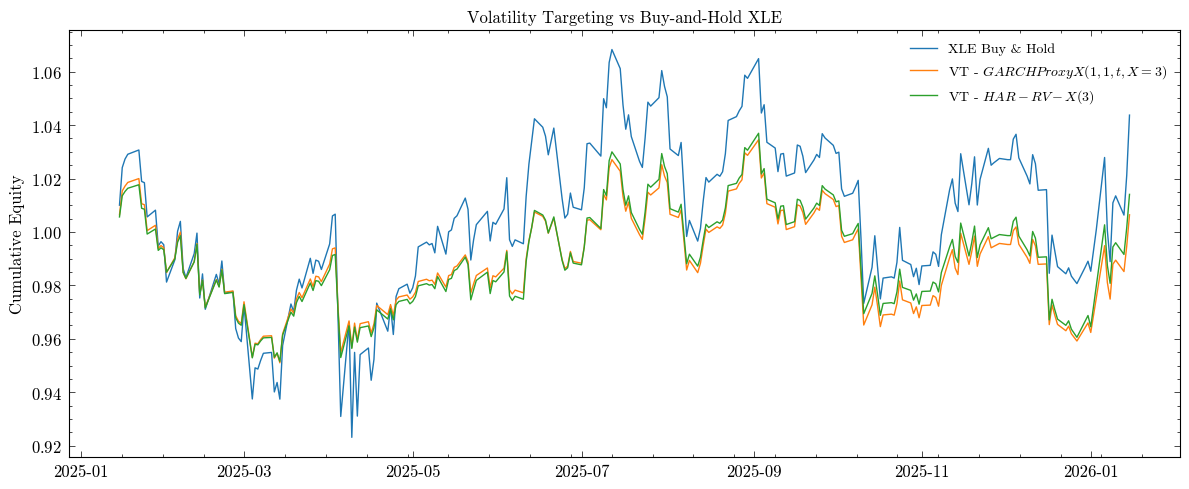

In [363]:

plt.figure(figsize=(12, 5))

plt.plot(xle_equity, label="XLE Buy & Hold")

for model, res in results.items():
    plt.plot(res["equity"], label=f"VT - ${model}$")

plt.legend()
plt.title("Volatility Targeting vs Buy-and-Hold XLE")
plt.ylabel("Cumulative Equity")
plt.tight_layout()
plt.savefig(f'../figures/vol_target.png', dpi = 300)
plt.show()


### Regime Swithcing

In [364]:
df

,ret_xle,rv_xle,truth,"EWMA(rv, λ=0.94)","GARCH(1,1)","GARCHProxyX(1,1,t,X=3)",HAR-RV,HAR-RV-X(3),XLE,oos
timestamp,,,,,,,,,,
2021-01-06 21:00:00+00:00,-0.353565,1.069716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07 21:00:00+00:00,0.466745,2.526196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08 21:00:00+00:00,-1.100503,3.264573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11 21:00:00+00:00,2.614148,2.235152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12 21:00:00+00:00,2.297663,3.475628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2026-01-08 21:00:00+00:00,2.227025,1.178230,1.178230,0.915678,1.445853,1.094204,1.193250,1.019042,46.549999,True
2026-01-09 21:00:00+00:00,0.257509,0.917744,0.917744,0.931431,1.591384,1.134139,1.139631,1.050643,46.669998,True
2026-01-12 21:00:00+00:00,-0.709752,1.128461,1.128461,0.930610,1.524962,1.074951,1.069445,1.031852,46.340000,True


In [365]:
from proj.models.regime_switching import fit_markov_regime_model, build_regime_table

In [366]:
results = []

for oos_day in for_trading.index:

    y = np.log(df.loc[:oos_day, 'rv_xle']).iloc[:-1]

    fit = fit_markov_regime_model(
        y=y,
        k_states=2,
        switching_variance=True,
        trend="c",
    )

    table = build_regime_table(fit, run_id=1)

    # extract OOS regime forecast
    row = table[['p_state_0_next', 'p_state_1_next']].iloc[-1]

    # reindex to OOS day
    row.name = oos_day

    results.append(row)


In [367]:
regime_oos = pd.DataFrame(results)
for_trading = for_trading.join(regime_oos, how="left")


In [368]:
for_trading

,ret_xle,rv_xle,truth,"EWMA(rv, λ=0.94)","GARCH(1,1)","GARCHProxyX(1,1,t,X=3)",HAR-RV,HAR-RV-X(3),XLE,oos,p_state_0_next,p_state_1_next
timestamp,,,,,,,,,,,,
2025-01-14 21:00:00+00:00,1.001602,1.015373,1.015373,1.105876,0.897145,0.955379,1.199641,1.257126,44.135769,True,0.175962,0.821452
2025-01-15 21:00:00+00:00,1.394535,1.254940,1.254940,1.100445,0.901654,0.983567,1.086795,1.246676,44.788948,True,0.340075,0.658492
2025-01-16 21:00:00+00:00,0.310904,0.504204,0.504204,1.109715,0.929437,1.220608,1.169641,1.496860,45.113117,True,0.384557,0.614386
2025-01-17 21:00:00+00:00,0.176134,0.259360,0.259360,1.073384,0.910312,0.678088,0.879542,0.884619,45.461483,True,0.889312,0.116289
2025-01-21 21:00:00+00:00,0.154987,0.520784,0.520784,1.024543,0.889930,0.472048,0.619556,0.570331,45.229240,True,0.963408,0.043532
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-08 21:00:00+00:00,2.227025,1.178230,1.178230,0.915678,1.445853,1.094204,1.193250,1.019042,46.549999,True,0.170963,0.821365
2026-01-09 21:00:00+00:00,0.257509,0.917744,0.917744,0.931431,1.591384,1.134139,1.139631,1.050643,46.669998,True,0.243199,0.750817
2026-01-12 21:00:00+00:00,-0.709752,1.128461,1.128461,0.930610,1.524962,1.074951,1.069445,1.031852,46.340000,True,0.481124,0.518419


In [369]:
for_trading[['p_state_1_next']].rolling(5).mean()


,p_state_1_next
timestamp,
2025-01-14 21:00:00+00:00,NaN
2025-01-15 21:00:00+00:00,NaN
2025-01-16 21:00:00+00:00,NaN
2025-01-17 21:00:00+00:00,NaN
2025-01-21 21:00:00+00:00,0.450830
...,...
2026-01-08 21:00:00+00:00,0.419054
2026-01-09 21:00:00+00:00,0.561782
2026-01-12 21:00:00+00:00,0.657080


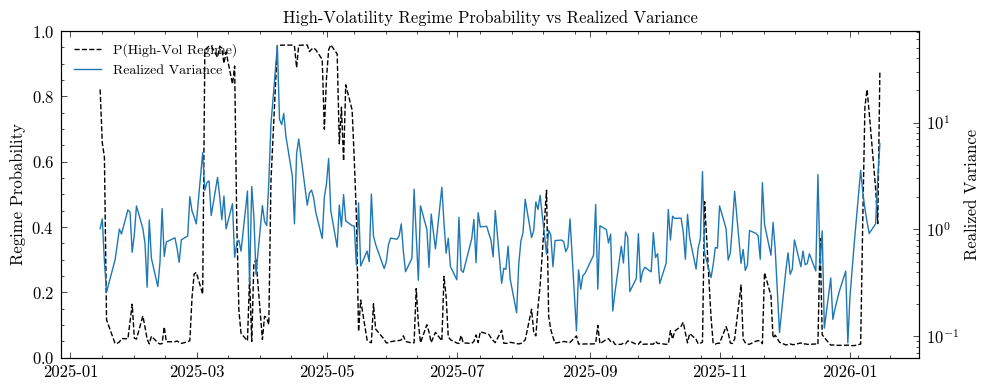

In [380]:

fig, ax1 = plt.subplots(figsize=(10, 4))

# Regime probability (smoothed)
ax1.plot(
    for_trading.index,
    for_trading['p_state_1_next'],
    label='P(High-Vol Regime)',
    color="black",
    linestyle='--'
)
ax1.set_ylabel('Regime Probability')
ax1.set_ylim(0, 1)

# Realized variance on second axis
ax2 = ax1.twinx()
ax2.plot(
    for_trading.index,
    for_trading['rv_xle'],
    label='Realized Variance'
)
ax2.set_ylabel('Realized Variance')

# Title
ax1.set_title('High-Volatility Regime Probability vs Realized Variance')

# Legend handling
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax2.set_yscale('log')
plt.tight_layout()
plt.savefig(f'../figures/p_regime_oos.png', dpi = 300)
plt.show()


In [371]:
def regime_switch_equity_pct(
    ret_pct: pd.Series,             # daily returns in % (2.24 means 2.24%)
    p_high_next: pd.Series,         # one-step-ahead prob of high-vol regime for trade day
    lag: int = 1,                   # use yesterday's regime signal for today's return
    ret_scale: str = "pct",         # "pct" or "bps"
    # allocation rule
    thr: float = 0.6,               # threshold on p_high_next
    w_low: float = 1.0,             # equity weight when NOT high regime (risk-on)
    w_high: float = 0.1,            # equity weight when high regime (risk-off)
    w_min: float = 0.0,
    w_max: float = 1.0,             # set >1.0 if you want leverage
    mode: str = "threshold",        # "threshold" or "smooth"
    smooth_k: float = 12.0,         # steepness for smooth switching
) -> pd.DataFrame:
    """
    Simple regime-switching allocation:
      - if p_high_next >= thr => allocate w_high to equity
      - else => allocate w_low to equity
    Returns:
      w: equity allocation weight
      ret: strategy return (decimal)
      equity: cumulative equity (starts at 1)
    """

    r = ret_pct.astype(float).copy()
    p = p_high_next.astype(float).copy()

    idx = r.index.intersection(p.index)
    r, p = r.loc[idx], p.loc[idx]

    # Guard: bps vs %
    if ret_scale == "bps":
        r = r / 100.0
    elif ret_scale != "pct":
        raise ValueError("ret_scale must be 'pct' or 'bps'")

    # build equity weight w_t from regime signal
    if mode == "threshold":
        w = np.where(p >= thr, w_high, w_low).astype(float)
        w = pd.Series(w, index=idx)
    elif mode == "smooth":
        # s ~ 0 when p << thr  (risk-on), s ~ 1 when p >> thr (risk-off)
        s = 1.0 / (1.0 + np.exp(-smooth_k * (p - thr)))
        w = (1.0 - s) * w_low + s * w_high
        w = pd.Series(w, index=idx)
    else:
        raise ValueError("mode must be 'threshold' or 'smooth'")

    w = w.clip(lower=w_min, upper=w_max)

    # apply with lag to avoid lookahead
    strat_ret = (w.shift(lag) * r).fillna(0.0) / 100.0  # percent -> decimal
    equity = (1.0 + strat_ret).cumprod()

    return pd.DataFrame({
        "w": w,
        "ret": strat_ret,
        "equity": equity,
        "p_high_next": p,
    })

In [372]:
def optimize_regime_threshold(
    ret_pct: pd.Series,
    p_high_next: pd.Series,
    thr_grid: np.ndarray = None,
    objective: str = "sharpe",     # "sharpe" or "cagr" etc.
    **strategy_kwargs
) -> tuple[float, pd.DataFrame]:
    """
    Returns (best_thr, results_df) where results_df includes metrics per threshold.
    """

    if thr_grid is None:
        thr_grid = np.linspace(0.50, 0.95, 19)  # 0.50, 0.525, ..., 0.95

    rows = []
    for thr in thr_grid:
        bt = regime_switch_equity_pct(
            ret_pct=ret_pct,
            p_high_next=p_high_next,
            thr=float(thr),
            **strategy_kwargs
        )
        stats = performance_stats(bt["ret"], ann_factor=strategy_kwargs.get("ann_factor", 252))
        rows.append({
            "thr": float(thr),
            **stats,
            "final_equity": float(bt["equity"].iloc[-1]) if len(bt) else np.nan,
            "avg_w": float(bt["w"].mean()) if len(bt) else np.nan,
        })

    res = pd.DataFrame(rows).sort_values(by=objective, ascending=False)
    best_thr = float(res.iloc[0]["thr"]) if len(res) else np.nan
    return best_thr, res

In [373]:
best_thr, grid = optimize_regime_threshold(
    ret_pct=for_trading["ret_xle"],
    p_high_next=for_trading["p_state_1_next"],
    thr_grid=np.linspace(0.50, 0.95, 10),
)


print(best_thr)
print(grid.head())


0.95
    thr  ann_return   ann_vol    sharpe  max_drawdown  n_days  final_equity  \
9  0.95    0.040210  0.146380  0.274699     -0.102411   252.0      1.040210   
8  0.90    0.009853  0.139992  0.070379     -0.116741   252.0      1.009853   
7  0.85   -0.021174  0.138140 -0.153278     -0.123263   252.0      0.978826   
6  0.80   -0.023843  0.133894 -0.178076     -0.120939   252.0      0.976157   
4  0.70   -0.041021  0.130797 -0.313625     -0.120939   252.0      0.958979   

      avg_w  
9  0.953571  
8  0.907143  
7  0.892857  
6  0.878571  
4  0.864286  


In [374]:
grid = grid.sort_values(by=['thr'])

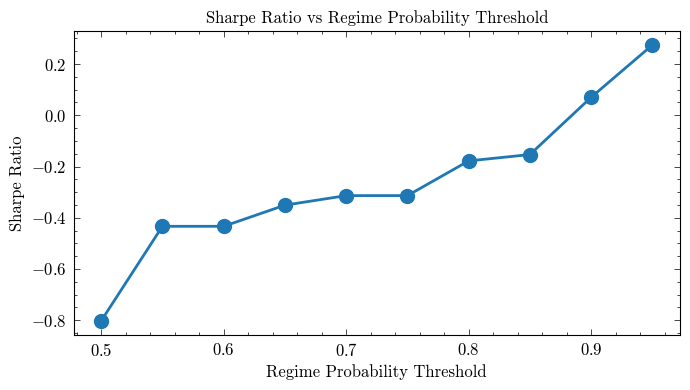

In [375]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    grid["thr"],
    grid["sharpe"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("Regime Probability Threshold")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Sharpe Ratio vs Regime Probability Threshold")

# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'../figures/threshold_optimization.png', dpi = 300)
plt.show()

### Plot all 

In [376]:
regime = regime_switch_equity_pct(
    ret_pct=for_trading["ret_xle"],
    p_high_next=for_trading["p_state_1_next"],
    thr=best_thr,
    w_low=1.0,
    w_high=0.2,
    lag=1,
    mode="threshold",
)


In [377]:
vol_target = vol_target_all_pct(
        ret_pct=for_trading["ret_xle"],
        var_pct2_daily=for_trading['GARCHProxyX(1,1,t,X=3)'],
        target_ann_vol_pct= float(historical_mean_rv_annual),
    )

In [378]:
xle_ret = for_trading["ret_xle"] / 100

xle_equity = (1 + xle_ret.fillna(0)).cumprod()

comparison = {}

# Buy-and-hold
comparison["XLE Buy & Hold"] = performance_stats(xle_ret)

results = {
    'regime switching':  regime,
     'volatility targeting': vol_target
}

for model, res in results.items():
    comparison[f"{model}"] = performance_stats(res["ret"])

perf_compare = pd.DataFrame(comparison).T
perf_compare


,ann_return,ann_vol,sharpe,max_drawdown,n_days
XLE Buy & Hold,0.043748,0.157188,0.278317,-0.104382,252.0
regime switching,0.039656,0.147395,0.269047,-0.101787,252.0
volatility targeting,0.006426,0.101149,0.063534,-0.072834,252.0


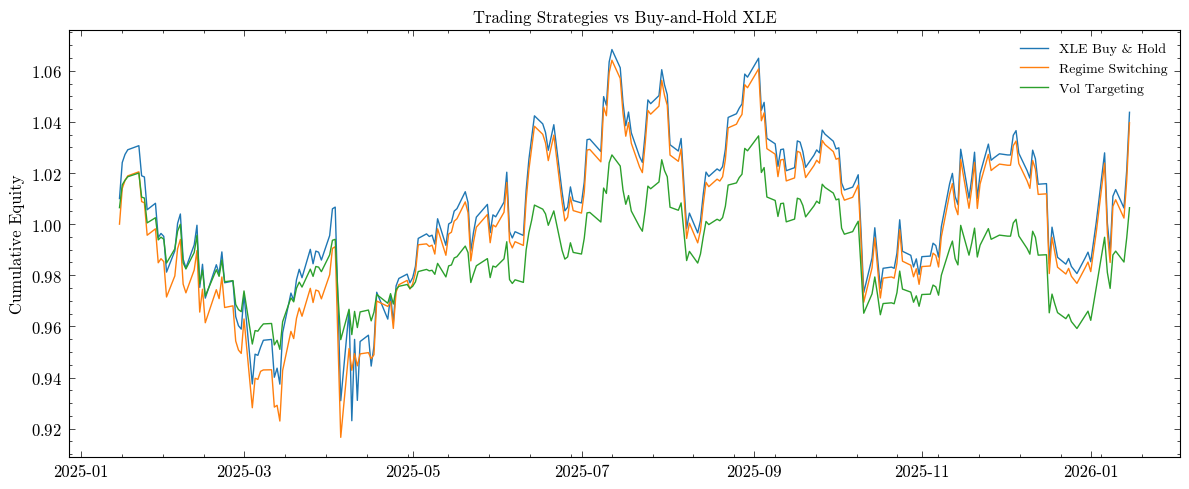

In [379]:
plt.figure(figsize=(12, 5))

plt.plot(xle_equity, label="XLE Buy & Hold")
plt.plot(regime['equity'], label='Regime Switching')
plt.plot(vol_target['equity'], label="Vol Targeting")
plt.legend()
plt.title("Trading Strategies vs Buy-and-Hold XLE")
plt.ylabel("Cumulative Equity")
plt.tight_layout()
plt.savefig(f'../figures/vol_trading.png', dpi = 300)
plt.show()
